<a href="https://colab.research.google.com/github/heoconngoc/Deep_Learning/blob/main/7_Convolutional_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Config & Import

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm    # lib for creating process bar when looping

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [2]:
# Load MNIST + Divide Train/Val/Test

transform = transforms.Compose([
    transforms.ToTensor(),    # Transform [0,255] -> [0,1]
    transforms.Normalize((0.1307,), (0.3081,)) # Normalize with mean and std
])

trainval_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds     = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# Divide train/val
train_size = int(0.9 * len(trainval_ds))
val_size   = len(trainval_ds) - train_size
train_ds, val_ds = random_split(trainval_ds, [train_size, val_size])

batch_size = 128
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

len(train_ds), len(val_ds), len(test_ds)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.86MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 154kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.00MB/s]


(54000, 6000, 10000)

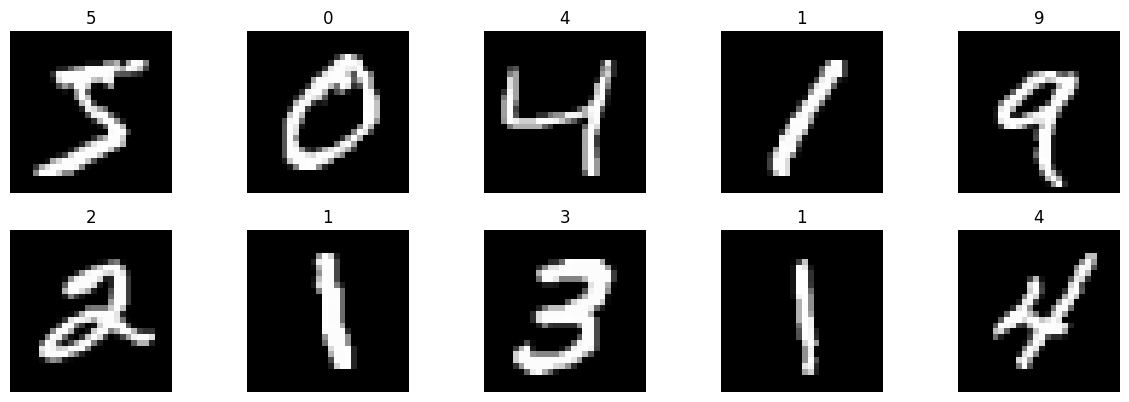

In [9]:
# Visualize few images in MNIST

def show_mnist_samples(dataset, n=10):
    cols = 5
    rows = (n + cols - 1)
    plt.figure(figsize=(12,2*rows))
    for i in range(n):
        x, y = dataset[i]
        # x shape: [1,28,28] normalized
        img = x[0].numpy() * 0.3081 + 0.1307  # unnormalize to see clearly

        plt.subplot(rows,cols,i+1)
        plt.imshow(img, cmap="gray")
        plt.title(str(y))
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_mnist_samples(trainval_ds, n=10)

In [12]:
# Define CNN architecture

class SimpleMNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)  # 28x28 -> 28x28, 16 feature maps
        self.pool1 = nn.MaxPool2d(2)                             # 28x28 -> 14x14. MaxPool2d is a kernel with size = 2

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1) # 14x14 -> 14x14, 32 feature maps
        self.pool2 = nn.MaxPool2d(2)                             # 14x14 -> 7x7

        self.fc1 = nn.Linear(32*7*7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)  # logits
        return x

model = SimpleMNISTCNN().to(device)
model


SimpleMNISTCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [13]:
activation = {}

def get_activation(name):
    def hook(model, input, output):
        activation[name] = output.detach().cpu()
    return hook

# register hook
model.conv1.register_forward_hook(get_activation("conv1"))
model.pool1.register_forward_hook(get_activation("pool1"))
model.conv2.register_forward_hook(get_activation("conv2"))
model.pool2.register_forward_hook(get_activation("pool2"))

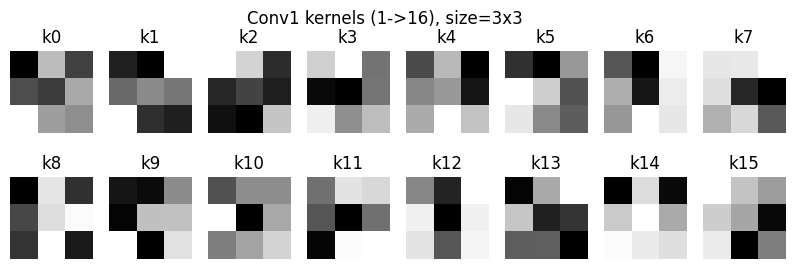

In [14]:
# Visualize kernels of Conv1

def show_conv1_kernels(model, max_kernels=16):
    W = model.conv1.weight.detach().cpu()  # [16,1,3,3]
    n = min(W.shape[0], max_kernels)
    plt.figure(figsize=(10,3))
    for i in range(n):
        plt.subplot(2, n//2, i+1)
        plt.imshow(W[i,0], cmap="gray")
        plt.title(f"k{i}")
        plt.axis("off")
    plt.suptitle("Conv1 kernels (1->16), size=3x3")
    plt.show()

show_conv1_kernels(model)

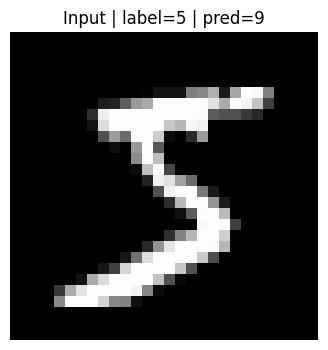

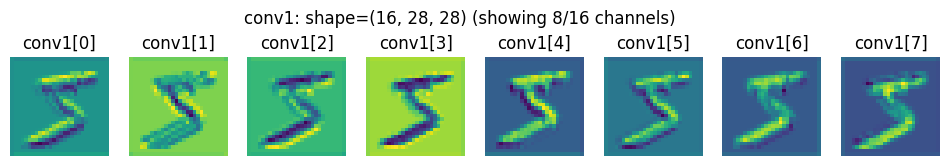

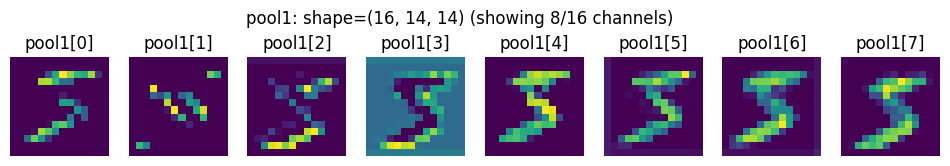

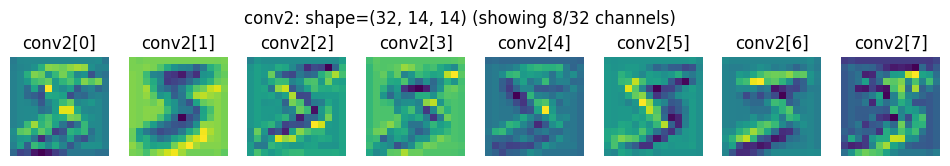

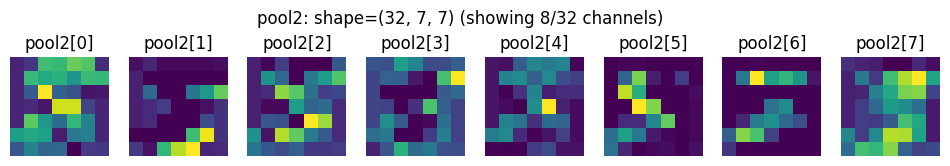

In [15]:
#  Visualize feature maps after each layer for 1 img

def unnormalize(x):
    # x: tensor [1,28,28] normalized
    return x * 0.3081 + 0.1307

def show_feature_maps_for_one(model, dataset, idx=0, max_channels=8):
    model.eval()
    x, y = dataset[idx]
    with torch.no_grad():
        logits = model(x.unsqueeze(0).to(device))
        pred = logits.argmax(dim=1).item()

    # input
    img = unnormalize(x).squeeze(0).numpy()

    plt.figure(figsize=(4,4))
    plt.imshow(img, cmap="gray")
    plt.title(f"Input | label={y} | pred={pred}")
    plt.axis("off")
    plt.show()

    # Get feature maps from dict activation
    for name in ["conv1", "pool1", "conv2", "pool2"]:
        fm = activation[name][0]  # [C,H,W]
        C = fm.shape[0]
        n = min(C, max_channels)

        plt.figure(figsize=(12, 2))
        for i in range(n):
            plt.subplot(1, n, i+1)
            plt.imshow(fm[i].numpy(), cmap="viridis")
            plt.title(f"{name}[{i}]")
            plt.axis("off")
        plt.suptitle(f"{name}: shape={tuple(fm.shape)} (showing {n}/{C} channels)")
        plt.show()

show_feature_maps_for_one(model, trainval_ds, idx=0, max_channels=8)

In [16]:
# Train/ Val loop + Cal accuracy

def accuracy_from_logits(logits, y):
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

def run_one_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss, total_acc, total_n = 0.0, 0.0, 0
    criterion = nn.CrossEntropyLoss()

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        if is_train:
            optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        if is_train:
            loss.backward()
            optimizer.step()

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc  += (logits.argmax(1) == y).float().sum().item()
        total_n    += bs

    return total_loss/total_n, total_acc/total_n

In [17]:
# Training model + Save best according to Val acc + plot curves

epochs = 8
lr = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

history = {
    "train_loss": [], "train_acc": [],
    "val_loss": [],   "val_acc": []
}

best_val_acc = 0.0
best_path = "mnist_cnn.pt"

for epoch in range(1, epochs+1):
    train_loss, train_acc = run_one_epoch(model, train_loader, optimizer)
    val_loss, val_acc     = run_one_epoch(model, val_loader, optimizer=None)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "model_state": model.state_dict(),
            "val_acc": best_val_acc,
            "epoch": epoch
        }, best_path)

    print(f"Epoch {epoch:02d}/{epochs} | "
          f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.4f} | best {best_val_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01/8 | train loss 0.2143 acc 0.9384 | val loss 0.0842 acc 0.9740 | best 0.9740
Epoch 02/8 | train loss 0.0630 acc 0.9806 | val loss 0.0616 acc 0.9815 | best 0.9815
Epoch 03/8 | train loss 0.0427 acc 0.9864 | val loss 0.0515 acc 0.9850 | best 0.9850
Epoch 04/8 | train loss 0.0329 acc 0.9894 | val loss 0.0420 acc 0.9877 | best 0.9877
Epoch 05/8 | train loss 0.0261 acc 0.9915 | val loss 0.0414 acc 0.9880 | best 0.9880
Epoch 06/8 | train loss 0.0191 acc 0.9940 | val loss 0.0412 acc 0.9872 | best 0.9880
Epoch 07/8 | train loss 0.0154 acc 0.9955 | val loss 0.0385 acc 0.9892 | best 0.9892
Epoch 08/8 | train loss 0.0127 acc 0.9958 | val loss 0.0407 acc 0.9885 | best 0.9892


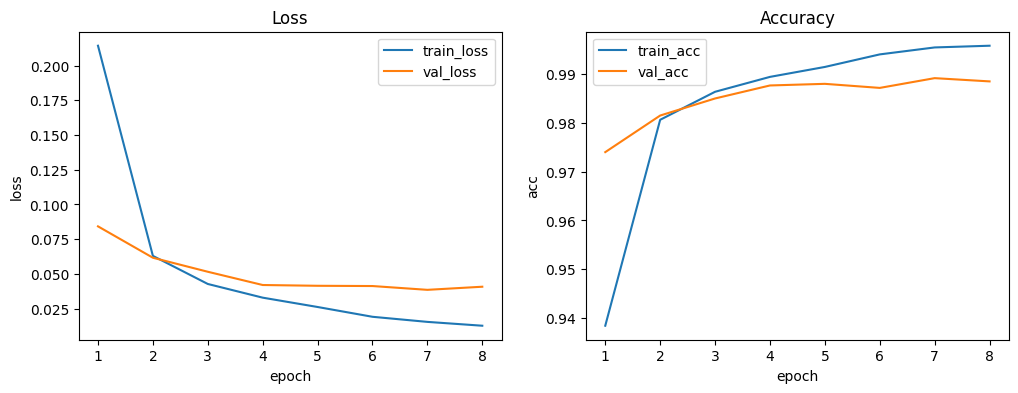

In [18]:
# Plot loss/ acc
def plot_history(history):
    epochs = range(1, len(history["train_loss"])+1)

    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("Loss")

    plt.subplot(1,2,2)
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch"); plt.ylabel("acc"); plt.legend(); plt.title("Accuracy")

    plt.show()

plot_history(history)

In [19]:
# Evaluate in Test set (Loss and Acc)

# Load best
ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()    # Turn into evaluate/ inference mode

test_loss, test_acc = run_one_epoch(model, test_loader, optimizer=None)
print("Best epoch:", ckpt["epoch"], "Best val_acc:", ckpt["val_acc"])
print("Test loss:", test_loss, "Test acc:", test_acc)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Best epoch: 7 Best val_acc: 0.9891666666666666
Test loss: 0.026944747173204088 Test acc: 0.9911


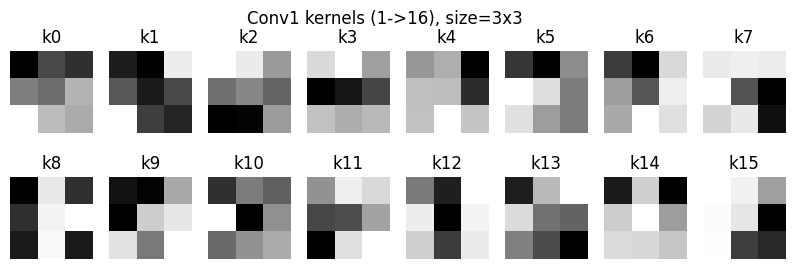

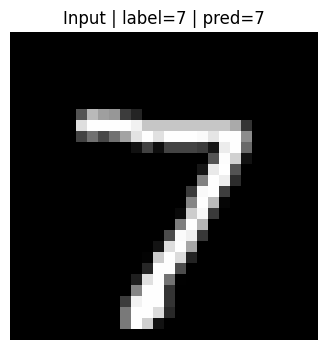

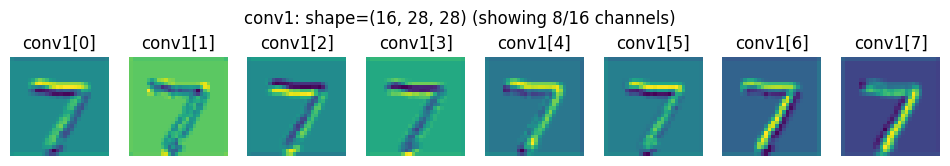

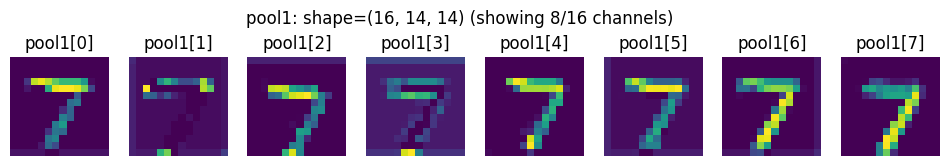

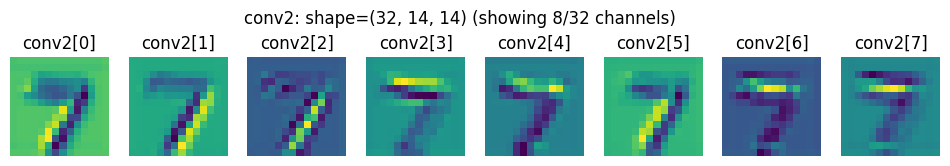

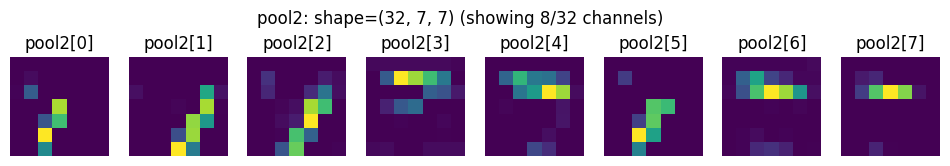

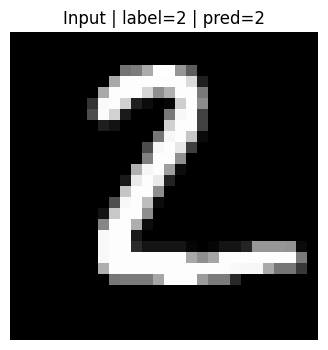

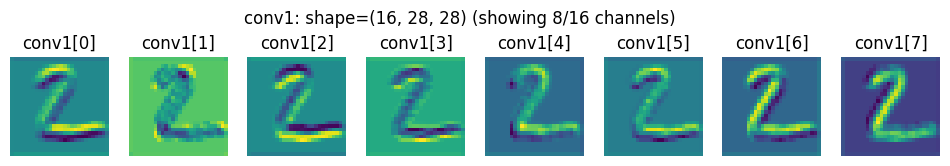

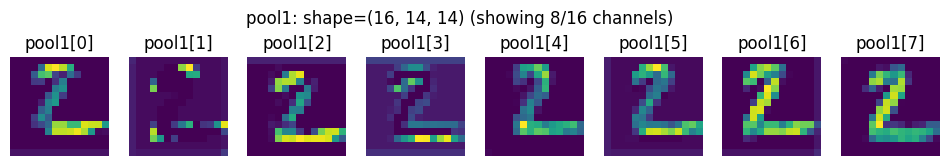

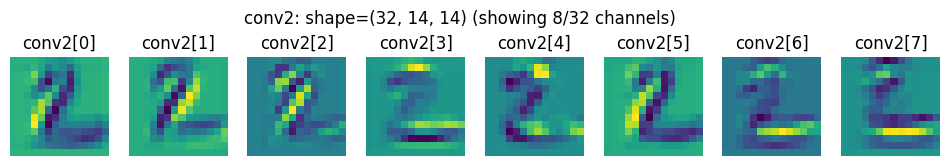

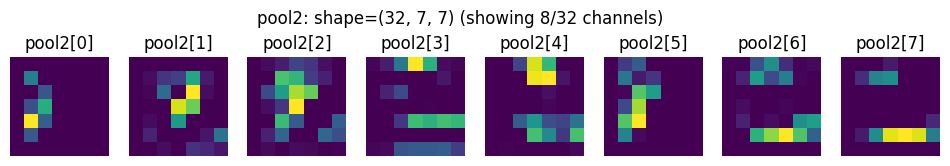

In [22]:
show_conv1_kernels(model)
show_feature_maps_for_one(model, test_ds, idx=0, max_channels=8)
show_feature_maps_for_one(model, test_ds, idx=1, max_channels=8)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


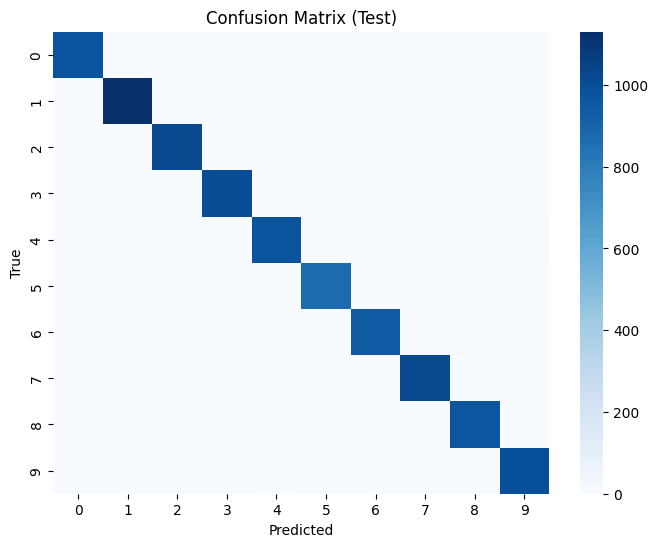

In [20]:
# Confusion matrix
# This is a table to evaluate classification model based on how many times it predict correctly,
# how many times it miss from one class to another

import seaborn as sns
from sklearn.metrics import confusion_matrix

def get_all_preds(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)
            preds = logits.argmax(1).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(y.numpy())
    return np.concatenate(all_preds), np.concatenate(all_labels)

preds, labels = get_all_preds(model, test_loader)
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix (Test)")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# How to save this model to personal device

from google.colab import files
files.download("mnist_cnn.pt")

In [ ]:
# Skeleton model application

def load_model(pt_path="mnist_cnn.pt"):
    m = SimpleMNISTCNN().to(device)
    ckpt = torch.load(pt_path, map_location=device)
    m.load_state_dict(ckpt["model_state"])
    m.eval()
    return m

model2 = load_model("mnist_cnn.pt")
